## Creating the "hello world" of ABM the Schelling's Segregation Model using only: variables, conditionals and arrays

In [1]:
import random
import matplotlib.pyplot as plt

In [2]:
def init_grid(grid,size,density):
    # create grid of 0
    for row in range(size):
        grid.append([])
        for col in range(size):
            grid[row].append(0)
    # set inner part to 1,2 or 0
    for row in range(1,size-1):
        for col in range(1,size-1):
            if random.random()<density:
                grid[row][col] = random.randint(1,2)
    

In [3]:
def count_neighbours(row,col,grid):
    state = grid[row][col]
    count =0
    neighbours =0
    for r in range(row-1,row+2):
        for c in range(col-1,col+2):
            if grid[r][c] >0:
                count+=1
            if grid[r][c] == state:
                neighbours+=1
    return neighbours, count

In [4]:
def move(grid,size,tolerance,row,col):
    if grid[row][col] >0:
        neighbours, count = count_neighbours(row,col,grid)
        if neighbours/count<tolerance:
            flag = False
            while flag == False:
                r = random.randint(1,size-2)
                c = random.randint(1,size-2)
                hold = grid[r][c]
                if hold == 0:
                    flag = True
                    grid[r][c] = grid[row][col]
                    grid[row][col] = 0

In [11]:
## Take this on faith
def plot_grid(grid):
    cmap = plt.cm.colors.ListedColormap(['white', 'red', 'blue'])
    plt.imshow(grid, cmap=cmap, vmin=0, vmax=2)
    plt.show()

initial grid


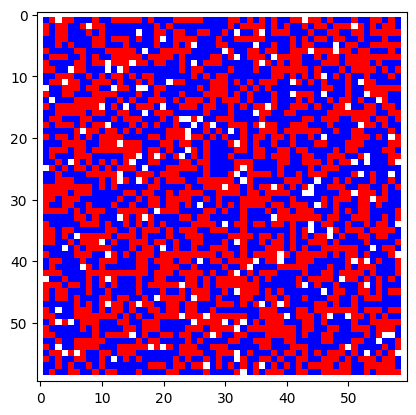

final grid


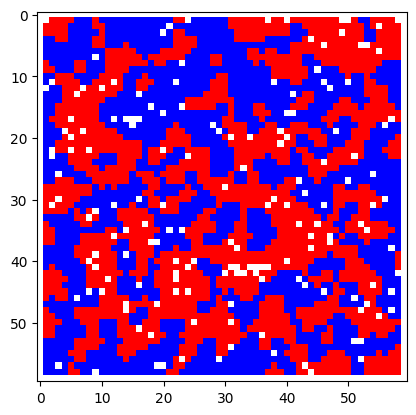

In [14]:
size = 60
density = 0.95
tolerance = 0.4
iterations = 40
grid=[]
init_grid(grid,size,density)
print("initial grid")
plot_grid(grid)
for i in range(iterations):
    ## note that the edge of the grid is not used to test for move 
    for row in range(1,size-1):
        for col in range(1,size-1):
            move(grid,size,tolerance,row,col)
print("final grid")
plot_grid(grid)


---

**What init_grid code does:**  
Creates a `size × size` grid (like a matrix), fills the borders with zeros, then randomly places values 1 or 2 inside (not on border) based on `density`.

---

**Line-by-line for an R/Java programmer:**

```python
def init_grid(grid, size, density):
```
- Like a function in R or Java. `grid` is passed by reference (like a list in Java or a vector in R).

```python
    for row in range(size):
```
- `range(size)` → 0, 1, 2, ..., size-1 (like `for(row in 0:(size-1))` in R, or `for(int row=0; row<size; row++)` in Java).

```python
        grid.append([])
```
- Adds an empty row to the list. In Java you'd do `grid.add(new ArrayList<>())`. In R, you'd grow a list.

```python
        for col in range(size):
            grid[row].append(0)
```
- Fills the row with `size` zeros (like adding elements to a list).

```python
    for row in range(1, size-1):
```
- `range(1, size-1)` → 1, 2, ..., size-2 (skips first and last row, like `for(row in 2:(size-1))` in R, or `for(int row=1; row<size-1; row++)` in Java).

```python
        for col in range(1, size-1):
```
- Same, but for columns (skips first and last column).

```python
            if random.random() < density:
```
- `random.random()` returns a float between 0 and 1. Like `runif(1)` in R, or `Math.random()` in Java.

```python
                grid[row][col] = random.randint(1, 2)
```
- Assigns either 1 or 2. Like `sample(1:2, 1)` in R, or `ThreadLocalRandom.current().nextInt(1, 3)` in Java.

---

**Key Python differences to note:**
- No explicit array/matrix declaration — lists of lists.
- `range(start, stop)` stops *before* `stop`.
- `append()` grows the list dynamically (no need to pre-allocate size).
- Indentation matters (no braces).


**What count_neighbours code does:**  
Looks at a cell at position `(row, col)` and counts two things:
1. **`neighbours`** = how many of the 8 surrounding cells (plus itself) have the *same* value as the center cell
2. **`count`** = how many of the 8 surrounding cells (plus itself) are *alive* (value > 0)

---

**Line-by-line:**

```python
def count_neighbours(row, col, grid):
```
- Function taking row, column, and the grid (passed by reference)

```python
    state = grid[row][col]
```
- `state` = the value of the center cell (1 or 2, or maybe 0)

```python
    count = 0
    neighbours = 0
```
- Initializes two counters (like `int count = 0` in Java, or `count <- 0` in R)

```python
    for r in range(row-1, row+2):
```
- Loops `r` from `row-1` to `row` (because `row+2` stops before `row+2`)  
- Example: if `row=5`, then `range(4,7)` → `4,5,6`  
- In R: `for(r in (row-1):(row+1))`  
- In Java: `for(int r = row-1; r <= row+1; r++)`

```python
        for c in range(col-1, col+2):
```
- Same for columns — gives a 3×3 block around the center cell

```python
            if grid[r][c] > 0:
                count += 1
```
- If cell has value 1 or 2, increment `count` (like `count++` in Java)

```python
            if grid[r][c] == state:
                neighbours += 1
```
- If cell has the same value as the center cell, increment `neighbours`

```python
    return neighbours, count
```
- Returns two values (like returning a vector in R, or an array in Java)

---

**Important to know for R/Java programmers:**

| Python | R equivalent | Java equivalent |
|--------|--------------|-----------------|
| `range(start, stop)` | `start:(stop-1)` | `for(i=start; i<stop; i++)` |
| `count += 1` | `count <- count + 1` | `count++` |
| `return a, b` | `return(c(a,b))` | `return new int[]{a,b}` |
| Indentation | Braces or `{}` | Braces `{}` |

---



**What move code does:**  
If a cell contains a living thing (1 or 2), it checks if less than tolerance of its neighbors (including itself) are the same type. If yes, the cell *moves* to a random empty spot elsewhere in the grid.

---

**Line-by-line:**

```python
def move(grid, size,tolerance, row, col):
```
- Function that takes the grid, its size, and the position of a cell to potentially move

```python
    if grid[row][col] > 0:
```
- Only do something if the cell is alive (has value 1 or 2)

```python
        neighbours, count = count_neighbours(row, col, grid)
```
- Calls the previous function. `neighbours` = how many cells (in 3×3 block) have same value as center. `count` = how many are alive (value >0).
- In R: `result <- count_neighbours(row,col,grid); neighbours <- result[1]; count <- result[2]`
- In Java: You'd need to return an array or two separate variables

```python
        if neighbours / count < tolerance:
```
- If the proportion of matching neighbors (including itself) is less than tolerance
- Example: If center cell = 2, and only 2 out of 9 cells in block are 2's, then 2/9 ≈ 0.22 < 0.5 → condition true

```python
            flag = False
```
- Creates a boolean variable (like `boolean flag = false;` in Java, or `flag <- FALSE` in R)

```python
            while flag == False:
```
- Keep looping until an empty spot is found (like `while(!flag)` in Java)

```python
                r = random.randint(1, size-2)
                c = random.randint(1, size-2)
```
- Picks random row and column **inside** the grid (not on border). `randint(1, size-2)` → from 1 to size-2 inclusive.
- In R: `r <- sample(1:(size-2), 1)`
- In Java: `r = ThreadLocalRandom.current().nextInt(1, size-1)`

```python
                hold = grid[r][c]
```
- Stores whatever is at that random position (probably 0, maybe something else)

```python
                if hold == 0:
                    flag = True
```
- If the random spot is empty, we can stop searching

```python
                    grid[r][c] = grid[row][col]
```
- Copy the value from the original cell to the new empty spot

```python
                    grid[row][col] = 0
```
- Empty out the original cell (the "creature" moved)

---

**Key Python differences to remember:**

| Python | R | Java |
|--------|---|------|
| `while flag == False:` | `while(!flag)` | `while(!flag)` |
| `random.randint(a,b)` | `sample(a:b, 1)` | `nextInt(a, b+1)` |
| Multiple assignment: `a, b = func()` | `a <- result[1]; b <- result[2]` | Need array or two lines |
| No explicit boolean type keywords | `TRUE`/`FALSE` | `true`/`false` |

---

**What the main code does:**  
Creates a 128×128 grid, fills it with random 1's and 2's (90% density), then repeatedly lets all cells try to move (40 times), and shows the before/after pictures.

---

**Line-by-line:**

```python
size = 128
```
- Sets grid size (like `int size = 128;` in Java, or `size <- 128` in R)

```python
grid = []
```
- Creates an empty list (like `ArrayList<ArrayList<Integer>> grid = new ArrayList<>();` in Java, or `grid <- list()` in R)

```python
init_grid(grid, size, 0.9)
```
- Calls the first function. Creates a `size × size` grid. `0.9` = 90% density (most cells start alive with value 1 or 2)

```python
print("initial grid")
```
- Prints text to console (like `System.out.println()` in Java, or `print()` in R)

```python
plot_grid(grid)
```
- Shows a picture of the starting grid (assuming this function exists elsewhere)

```python
for i in range(40):
```
- Outer loop: repeats everything inside 40 times  
- `range(40)` → 0, 1, 2, ..., 39  
- In R: `for(i in 1:40)`  
- In Java: `for(int i=0; i<40; i++)`

```python
    for row in range(1, size-1):
        for col in range(1, size-1):
```
- Nested loops: visits every cell **except the border** (rows 1 to 126, cols 1 to 126)
- Total iterations per outer loop: `126 × 126 = 15,876` cells

```python
            move(grid, size, row, col)
```
- Tries to move the creature at position `(row, col)` according to the move rules from before

```python
print("final grid")
plot_grid(grid)
```
- After 40 complete passes through the entire grid, shows the final picture

---

**What happens in plain English:**

1. **Start:** Create a 128×128 board. Fill 90% of cells with random 1's or 2's. Show picture.
2. **For 40 rounds:**
   - Look at every single cell (except border)
   - For each cell, if it's a 1 or 2 that's lonely (<50% same neighbors), move it to a random empty spot
3. **End:** Show the final picture

---

**Important to note for R/Java programmers:**

| Python | R | Java |
|--------|---|------|
| `for i in range(40):` | `for(i in 1:40)` | `for(int i=0; i<40; i++)` |
| `grid = []` | `grid <- list()` | `new ArrayList<>()` |
| `print("text")` | `print("text")` | `System.out.println("text")` |
| No semicolons | Semicolons optional | Semicolons required |
| Indentation = block | Braces or indentation | Braces `{}` |

---
